**Annual count of impacting (100km ring) and landfall TCs over PH. 7 categories:**

1.   TD + TS
1.   CAT 1
1.   CAT 2
1.   CAT 3
2.   CAT 4
2.   CAT 5
2.   CAT 1 - 3
1.   CAT 4 - 5

In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

In [17]:
tc_points = gpd.read_file(r'C:\Users\luxi\OneDrive - Peak Reinsurance Company Ltd\Documents\ClimateRisk\TC\00 - Data\IBTrACS.WP.list.v04r01.points\IBTrACS.WP.list.v04r01.points.shp')
lines = gpd.read_file(r'C:\Users\luxi\OneDrive - Peak Reinsurance Company Ltd\Documents\ClimateRisk\TC\00 - Data\IBTrACS.WP.list.v04r01.lines\IBTrACS.WP.list.v04r01.lines.shp')
phl_buffer = gpd.read_file("PHL_1degree_buffer.shp")
phl_land = gpd.read_file("PHL_adm0.shp")

In [18]:
tc_points = tc_points[(tc_points['SEASON'] >= 1980) & (tc_points['SEASON'] <= 2024)]

In [19]:
def categorize_tc(wind):
    if pd.isna(wind):
        return None
    if wind >= 137:
        return 'Category 5'
    elif wind >= 113:
        return 'Category 4'
    elif wind >= 96:
        return 'Category 3'
    elif wind >= 83:
        return 'Category 2'
    elif wind >= 64:
        return 'Category 1'
    elif wind > 34:
        return 'Tropical Storm'
    return 'Tropical depression'

In [20]:
tc_points['category'] = tc_points['USA_WIND'].apply(categorize_tc)

In [21]:
tc_points = tc_points.to_crs(epsg=4326)
phl_buffer = phl_buffer.to_crs(epsg=4326)
phl_land = phl_land.to_crs(epsg=4326)

In [22]:
impacting_points = gpd.sjoin(tc_points, phl_buffer[['geometry']], how='inner', predicate='within')
landfall_points = gpd.sjoin(tc_points, phl_land[['geometry']], how='inner', predicate='intersects')


In [23]:
def get_max_category(group):
    categories = ['Category 5','Category 4','Category 3','Category 2','Category 1','Tropical Storm','Tropical depression']
    for cat in categories:
        if cat in group['category'].values:
            return cat

In [24]:
# Impacting TCs
impacting_tcs = impacting_points.groupby(['SID', 'year']).apply(get_max_category).reset_index().rename(columns={0: 'category'})
impacting_tcs = impacting_tcs[impacting_tcs['category'].notnull()]
impacting_counts = impacting_tcs.groupby(['year', 'category']).size().unstack(fill_value=0)
print(impacting_tcs.shape)

# Landfall TCs
landfall_tcs = landfall_points.groupby(['SID', 'year']).apply(get_max_category).reset_index().rename(columns={0: 'category'})
landfall_tcs = landfall_tcs[landfall_tcs['category'].notnull()]
landfall_counts = landfall_tcs.groupby(['year', 'category']).size().unstack(fill_value=0)
print(landfall_tcs.shape)


(406, 3)
(296, 3)


In [25]:
duplicate_sids_landfall = landfall_tcs[landfall_tcs['SID'].duplicated(keep=False)]
print(duplicate_sids_landfall.shape)
if not duplicate_sids_landfall.empty:
    print("Duplicate SIDs found:")
    print(duplicate_sids_landfall[['SID', 'year', 'category']].sort_values(by='SID'))
    print(f"\nTotal number of duplicate landfall_tcs SID entries: {len(duplicate_sids_landfall)}")
else:
    print("No duplicate SIDs found in the DataFrame.")

(0, 3)
No duplicate SIDs found in the DataFrame.


In [26]:
duplicate_sids_impacting = impacting_tcs[impacting_tcs['SID'].duplicated(keep=False)]
print(duplicate_sids_impacting.shape)
if not duplicate_sids_impacting.empty:
    print("Duplicate SIDs found:")
    print(duplicate_sids_impacting[['SID', 'year', 'category']].sort_values(by='SID'))
    print(f"\nTotal number of duplicate impacting_tcs SID entries: {len(duplicate_sids_impacting)}")
else:
    print("No duplicate SIDs found in the DataFrame.")

(2, 3)
Duplicate SIDs found:
              SID  year             category
71  1986353N03178  1986       Tropical Storm
72  1986353N03178  1987  Tropical depression

Total number of duplicate impacting_tcs SID entries: 2


In [ ]:
# check the duplicate rows in impacting tc 
#tc_points[tc_points['SID'].isin(duplicate_sids_impacting['SID'])].tail(20)

In [27]:
# Ensure all categories are present
for cat in ['Category 5','Category 4','Category 3','Category 2','Category 1','Tropical Storm','Tropical depression']:
    if cat not in impacting_counts.columns:
        impacting_counts[cat] = 0

# Compute All TCs (sum of Tropical Storm and CAT 1-5 )
impacting_counts['TS + TD'] = impacting_counts[['Tropical Storm','Tropical depression']].sum(axis=1)
landfall_counts['TS + TD']  = landfall_counts[['Tropical Storm','Tropical depression']].sum(axis=1)

impacting_counts['CAT 1'] = impacting_counts[['Category 1',]].sum(axis=1)
landfall_counts['CAT 1'] = landfall_counts[['Category 1',]].sum(axis=1)

impacting_counts['CAT 2'] = impacting_counts[['Category 2',]].sum(axis=1)
landfall_counts['CAT 2'] = landfall_counts[['Category 2',]].sum(axis=1)

impacting_counts['CAT 3'] = impacting_counts[['Category 3',]].sum(axis=1)
landfall_counts['CAT 3'] = landfall_counts[['Category 3',]].sum(axis=1)

impacting_counts['CAT 4'] = impacting_counts[['Category 4']].sum(axis=1)
landfall_counts['CAT 4'] = landfall_counts[['Category 4']].sum(axis=1)

impacting_counts['CAT 5'] = impacting_counts[['Category 5']].sum(axis=1)
landfall_counts['CAT 5'] = landfall_counts[['Category 5']].sum(axis=1)

impacting_counts['CAT 1 - 2'] = impacting_counts[['Category 1','Category 2']].sum(axis=1)
landfall_counts['CAT 1 - 2'] = landfall_counts[['Category 1','Category 2']].sum(axis=1)

impacting_counts['CAT 3 - 5'] = impacting_counts[['Category 3','Category 4','Category 5']].sum(axis=1)
landfall_counts['CAT 3 - 5'] = landfall_counts[['Category 3','Category 4','Category 5']].sum(axis=1)

impacting_counts['All'] = impacting_counts[['TS + TD','CAT 1','CAT 2','CAT 3','CAT 4','CAT 5']].sum(axis=1)
landfall_counts['All'] = landfall_counts[['TS + TD','CAT 1','CAT 2','CAT 3','CAT 4','CAT 5']].sum(axis=1)

# Reorder columns
categories = ['TS + TD','CAT 1','CAT 2','CAT 3','CAT 4','CAT 5','CAT 1 - 2','CAT 3 - 5','All']
impacting_counts = impacting_counts[categories]
landfall_counts = landfall_counts[categories]

In [28]:
landfall_counts

category,TS + TD,CAT 1,CAT 2,CAT 3,CAT 4,CAT 5,CAT 1 - 2,CAT 3 - 5,All
year,,,,,,,,,
1980,5,1,0,2,0,0,1,2,8
1981,4,2,0,0,0,0,2,0,6
1982,5,1,1,1,0,0,2,1,8
1983,4,1,0,0,0,0,1,0,5
1984,2,0,0,1,1,0,0,2,4
1985,1,1,1,0,0,0,2,0,3
1986,5,1,1,0,0,0,2,0,7
1987,2,1,1,1,1,1,2,3,7
1988,5,1,0,1,1,0,1,2,8


In [29]:
impacting_counts

category,TS + TD,CAT 1,CAT 2,CAT 3,CAT 4,CAT 5,CAT 1 - 2,CAT 3 - 5,All
year,,,,,,,,,
1980,6,0,2,0,2,0,2,2,10
1981,3,1,1,1,1,0,2,2,7
1982,3,2,1,2,0,0,3,2,8
1983,7,1,0,0,1,0,1,1,9
1984,4,0,1,0,2,0,1,2,7
1985,2,1,1,0,1,0,2,1,5
1986,6,1,1,1,0,0,2,1,9
1987,3,0,2,1,0,2,2,3,8
1988,6,1,1,1,2,0,2,3,11


In [30]:
landfall_counts_column_sums = landfall_counts.sum()
result1 = landfall_counts_column_sums / 45
std_devs = landfall_counts.std()

result1 = pd.DataFrame({
    'Sum': landfall_counts_column_sums,
    'Annual mean number': result1,
    'Standard Deviation': std_devs
})

result1

,Sum,Annual mean number,Standard Deviation
category,,,
TS + TD,193,4.288889,2.492007
CAT 1,36,0.800000,0.868646
CAT 2,20,0.444444,0.623610
CAT 3,20,0.444444,0.586033
CAT 4,22,0.488889,0.661342
CAT 5,5,0.111111,0.317821
CAT 1 - 2,56,1.244444,1.069315
CAT 3 - 5,47,1.044444,0.928233
All,296,6.577778,2.895835


In [31]:
# Save to CSV
result1.to_csv('landfall_counts_average.csv', index_label='Category')

print("CSV file 'landfall_counts_average.csv' has been generated.")

CSV file 'landfall_counts_average.csv' has been generated.


In [32]:
landfall_counts_column_sums

category
TS + TD      193
CAT 1         36
CAT 2         20
CAT 3         20
CAT 4         22
CAT 5          5
CAT 1 - 2     56
CAT 3 - 5     47
All          296
dtype: int64

In [33]:
impacting_counts_column_sums = impacting_counts.sum()
result2 = impacting_counts_column_sums / 45
result2

category
TS + TD      5.800000
CAT 1        0.800000
CAT 2        0.666667
CAT 3        0.466667
CAT 4        0.822222
CAT 5        0.466667
CAT 1 - 2    1.466667
CAT 3 - 5    1.755556
All          9.022222
dtype: float64

In [34]:
impacting_counts_column_sums

category
TS + TD      261
CAT 1         36
CAT 2         30
CAT 3         21
CAT 4         37
CAT 5         21
CAT 1 - 2     66
CAT 3 - 5     79
All          406
dtype: int64

In [35]:
bypassing = impacting_counts_column_sums - landfall_counts_column_sums

In [36]:
bypassing

category
TS + TD       68
CAT 1          0
CAT 2         10
CAT 3          1
CAT 4         15
CAT 5         16
CAT 1 - 2     10
CAT 3 - 5     32
All          110
dtype: int64

In [37]:
result3 = bypassing / 45

std_devs1 = bypassing.std()

result3 = pd.DataFrame({
    'Sum': bypassing,
    'Annual mean number': result3,
    'Standard Deviation': std_devs
})


result3

,Sum,Annual mean number,Standard Deviation
category,,,
TS + TD,68,1.511111,2.492007
CAT 1,0,0.000000,0.868646
CAT 2,10,0.222222,0.623610
CAT 3,1,0.022222,0.586033
CAT 4,15,0.333333,0.661342
CAT 5,16,0.355556,0.317821
CAT 1 - 2,10,0.222222,1.069315
CAT 3 - 5,32,0.711111,0.928233
All,110,2.444444,2.895835


In [38]:

# Save to CSV
result3.to_csv('bypassing_counts_average.csv', index_label='Category')

print("CSV file 'bypassing_counts_average.csv' has been generated.")

CSV file 'bypassing_counts_average.csv' has been generated.


In [39]:
def calculate_slope(years, values):
    coefficients = np.polyfit(years, values, 1)
    return coefficients[0]  # Return slope (m from y = mx + b)


In [43]:
impacting_counts.index

Index([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='year')

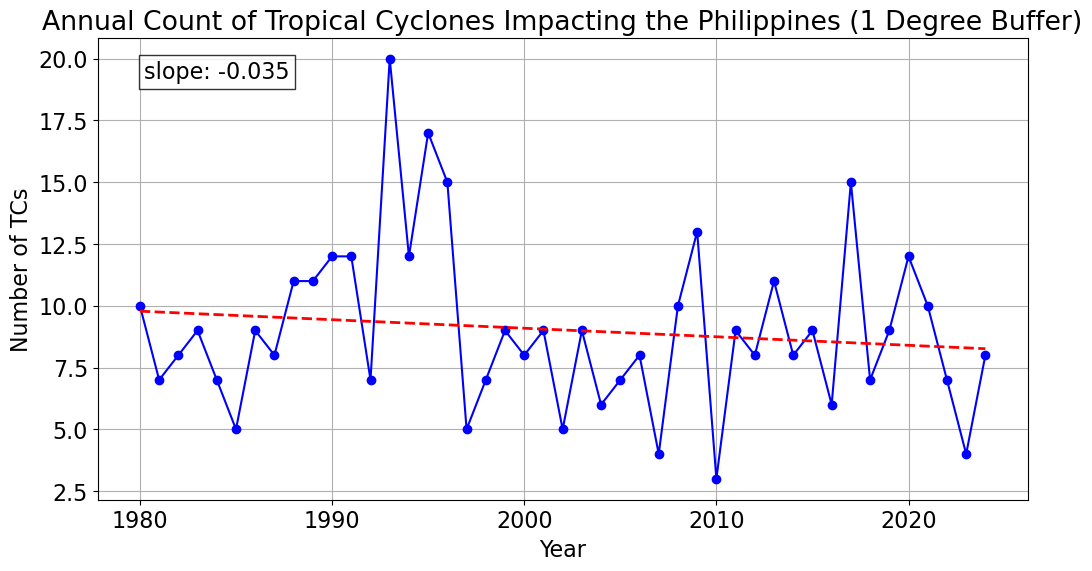

In [56]:
#// set fontsize of axis labels, legend and title all to 16
plt.rcParams.update({'font.size': 16})

select_category = 'All'  # Change this to the desired category
fig = plt.figure(figsize=(12, 6))
plt.plot(impacting_counts.index, impacting_counts[select_category], label=select_category, marker='o', color='blue')
plt.title('Annual Count of Tropical Cyclones Impacting the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts[select_category], 1)
p = np.poly1d(z)
plt.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_ts_td = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'slope: {z[0]:.3f}', transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
#plt.legend()
plt.grid(True)
plt.show()

fig.savefig(f'{select_category}_TC_frequency_trends.png',bbox_inches='tight')

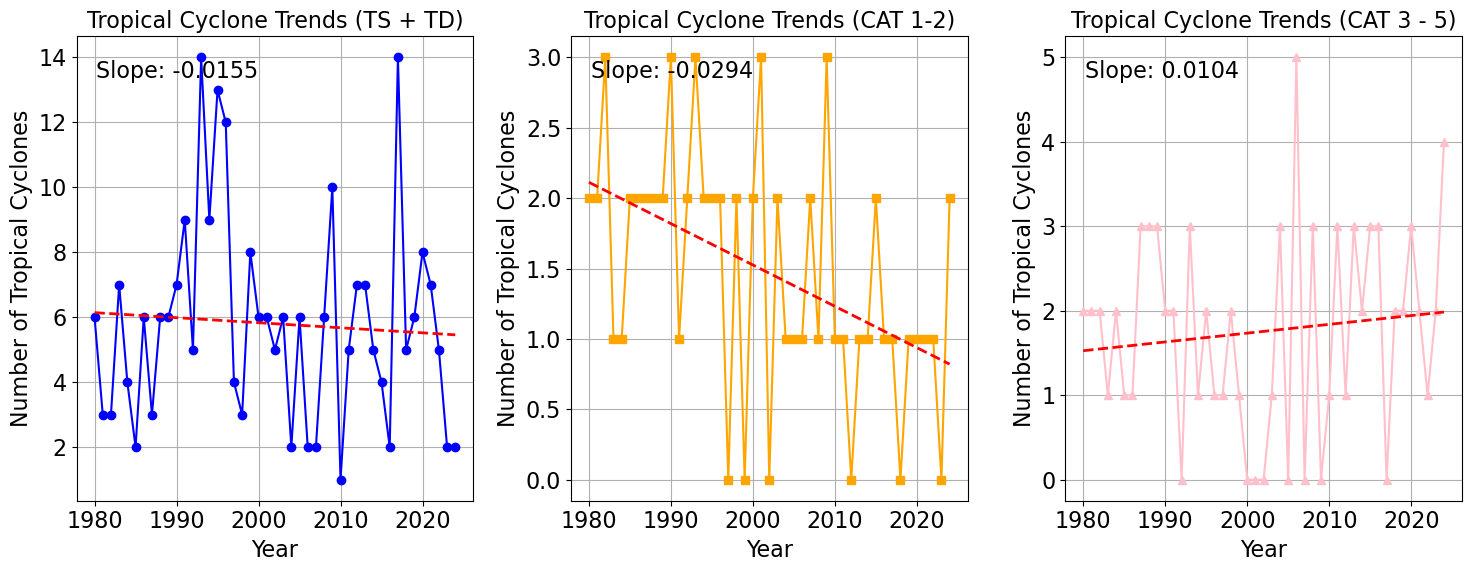

In [57]:
# Create figure with 4 subplots
fig, ((ax4,ax2, ax3)) = plt.subplots(1, 3, figsize=(15, 6))

# Calculate slopes for Plot 1
#slope_ts_td = calculate_slope(impacting_counts.index, impacting_counts['TS + TD'])
#slope_cat1_2 = calculate_slope(impacting_counts.index, impacting_counts['CAT 1 - 2'])
#slope_cat3_5 = calculate_slope(impacting_counts.index, impacting_counts['CAT 3 - 5'])
#ax1.text(0.05, 0.95, f'Slope TS + TD: {slope_ts_td:.4f}\nSlope CAT 1-2: {slope_cat1_3:.4f}\nSlope CAT 3-5: {slope_cat4_5:.4f}',
#         transform=ax1.transAxes, fontsize=16, verticalalignment='top')

# Plot 2: CAT 1-2 only
ax2.plot(impacting_counts.index, impacting_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='s', color='orange')
ax2.set_title('Tropical Cyclone Trends (CAT 1-2)', fontsize=16)
ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('Number of Tropical Cyclones', fontsize=16)
# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 1 - 2'], 1)
p = np.poly1d(z)
ax2.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')
#ax2.legend(fontsize=16)
ax2.grid(True)
ax2.text(0.05, 0.95, f'Slope: {z[0]:.4f}', transform=ax2.transAxes, fontsize=16, verticalalignment='top')
ax2.tick_params(axis='both', which='major', labelsize=16)

# Plot 3: CAT 3 - 5 only
ax3.plot(impacting_counts.index, impacting_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='^', color='pink')
ax3.set_title('Tropical Cyclone Trends (CAT 3 - 5)', fontsize=16)
ax3.set_xlabel('Year', fontsize=16)
ax3.set_ylabel('Number of Tropical Cyclones', fontsize=16)
# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 3 - 5'], 1)
p = np.poly1d(z)
ax3.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')
#ax3.legend(fontsize=16)
ax3.grid(True)
ax3.text(0.05, 0.95, f'Slope: {z[0]:.4f}', transform=ax3.transAxes, fontsize=16, verticalalignment='top')
ax3.tick_params(axis='both', which='major', labelsize=16)

# Plot 4: TS + TD only
ax4.plot(impacting_counts.index, impacting_counts['TS + TD'], label='TS + TD', marker='o', color='blue')
ax4.set_title('Tropical Cyclone Trends (TS + TD)', fontsize=16)
ax4.set_xlabel('Year', fontsize=16)
ax4.set_ylabel('Number of Tropical Cyclones', fontsize=16)

# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['TS + TD'], 1)
p = np.poly1d(z)
ax4.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')
#ax4.legend(fontsize=16)
ax4.grid(True)
ax4.text(0.05, 0.95, f'Slope: {z[0]:.4f}', transform=ax4.transAxes, fontsize=16, verticalalignment='top')
ax4.tick_params(axis='both', which='major', labelsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()
fig.savefig('TC_frequency_trends_by_category.png', bbox_inches='tight')

# Print slopes
#print("Slopes of the trend lines:")
#print(f"TS + TD: {slope_ts_td:.4f}")
#print(f"CAT 1-2: {slope_cat1_3:.4f} ")
#print(f"CAT 3-5: {slope_cat4_5:.4f} ")